Device: cpu
the noise variance is: 3.6793718338012695
MCMC step size gamma = 0.980600
Running Warm up     



  0%|          | 0/999 [00:00<?, ?it/s]


Running SAPG algorithm     



  0%|          | 0/1027 [00:00<?, ?it/s]


Estimated theta  = 0.127512
Estimated sigma2 = 100.000000
True sigma2      = 3.679372


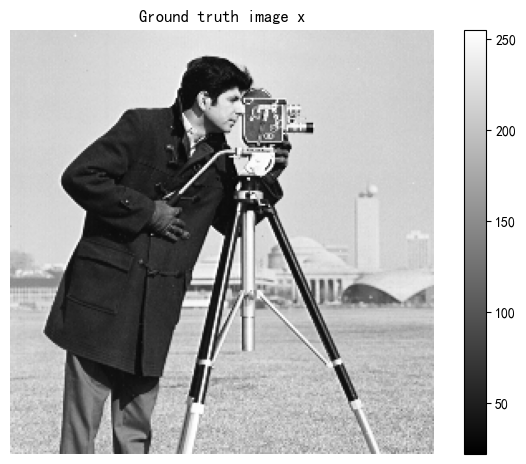

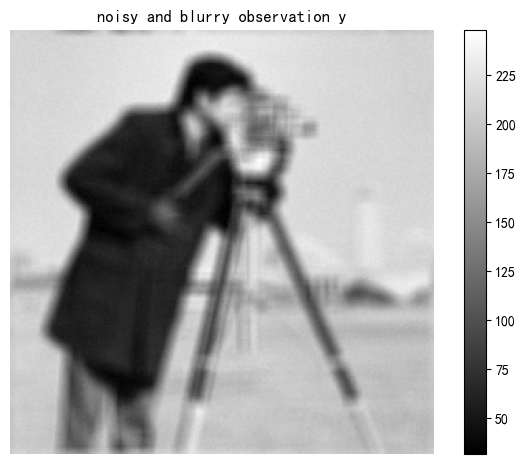

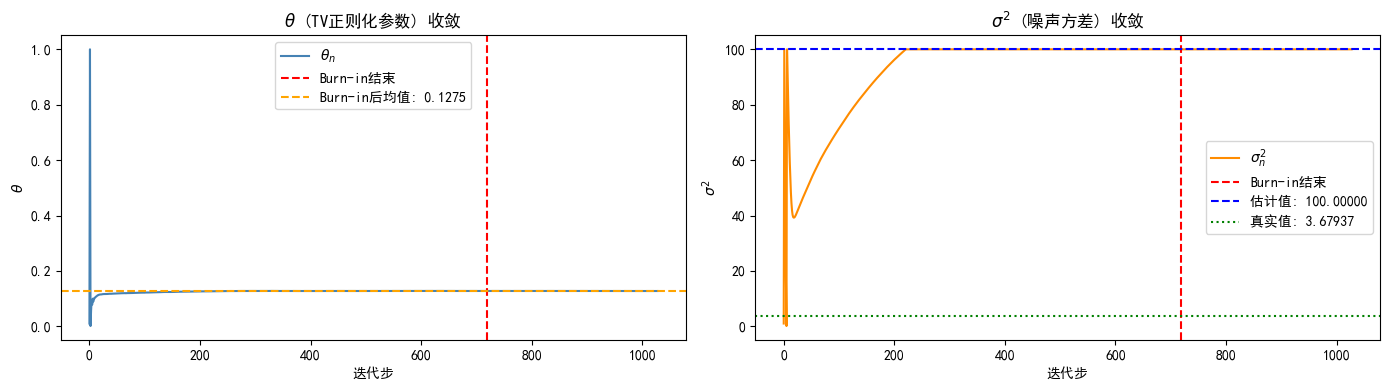


Running MAP reconstruction with estimated parameters...


  0%|          | 0/200 [00:00<?, ?it/s]


观测 SNR:  16.62 dB
MAP SNR:   15.88 dB
SNR提升:   -0.73 dB


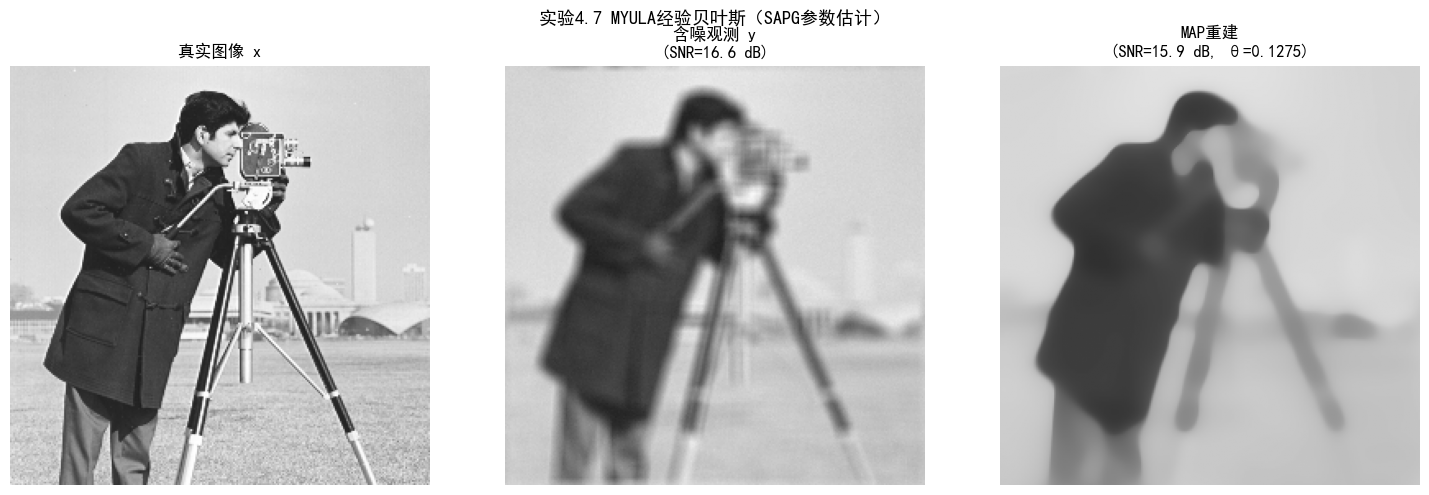


=== 总结 ===
估计 θ   : 0.127512
估计 σ²  : 100.000000
真实 σ²  : 3.679372
SNR提升  : -0.73 dB


In [2]:
"""
实验4.7 MYULA经验贝叶斯（参数自适应估计）
对应章节：4.4（MYULA、近端TV）、3.6（经验贝叶斯、边际似然）
素材来源：Mathematics.../Teaching Unit 6/Unit2_exercise.ipynb
  - Cell 3: 导入和设备设置
  - Cell 4-6: 图像加载、模糊算子、含噪观测
  - Cell 7: 似然定义（填空→参照答案填写）
  - Cell 8: TV范数函数
  - Cell 9: 近端TV算子（Chambolle算法）和MYULA梯度
  - Cell 10: 后验对数密度（填空→参照答案填写）
  - Cell 11: MCMC步长（填空→参照答案填写）
  - Cell 12-13: SAPG参数
  - Cell 14: MYULA暖启动（填空→参照答案填写）
  - Cell 15: 对数尺度参数
  - Cell 16: SAPG主循环（填空→参照答案填写）
  - Cell 17: 结果评估（参照答案填写）
  辅助模块：sampling_tools/ (已拷贝到当前目录)
  答案来源：Unit2_exercise_solution.ipynb
"""

import numpy as np
import torch
from scipy.linalg import norm
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

from PIL import Image

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

import sys
import os

# sampling_tools 已拷贝到当前目录
SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
if SCRIPT_DIR not in sys.path:
    sys.path.append(SCRIPT_DIR)

from sampling_tools import *

from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ============================================================
# 图像和正向模型（逐字取自 Unit2_exercise Cell 4-6）
# ============================================================
x = np.array(Image.open(os.path.join(SCRIPT_DIR, "cman.png"))).astype(np.float64)
plot_im(x, "Ground truth image x")

nx, ny = x.shape
dimx = nx * ny

x = torch.Tensor(x).to(device)

kernel_len = [9,9]
type_blur = "uniform"
A, AT, AAT_norm = blur_operators(kernel_len, (nx, ny), type_blur, device)

# 含噪观测
Ax = A(x)
BSNR = 30
sigma = torch.linalg.matrix_norm(Ax-torch.mean(Ax), ord='fro')/math.sqrt(dimx*10**(BSNR/10))
y = Ax + sigma*torch.randn_like(x)

plot_im(y, "noisy and blurry observation y")
print(f"the noise variance is: {sigma**2}")

# ============================================================
# 似然（取自答案 Cell 7）
# f_y^{σ²}(x) = ||y - Ax||_F² / (2σ²)
# ============================================================
# define the likelihood here
f_y = lambda x, sigma2: (torch.linalg.matrix_norm(y - A(x), ord='fro')**2) / (2 * sigma2)

# define the gradient of the negative log-likelihood w.r.t. sigma^2 here
# 注意：答案定义为正值 ||y-Ax||²/(2σ⁴)，SAPG中取负号
grad_f_sigma2 = lambda x, sigma2: (torch.linalg.matrix_norm(y - A(x), ord='fro')**2) / (2 * sigma2**2)

# define the gradient of the negative log-likelihood w.r.t. x here
# ∇_x f = A^T(Ax - y) / σ²
grad_f_x = lambda x, sigma2: AT(A(x) - y) / sigma2

# ============================================================
# TV先验和近端算子（取自 Unit2_exercise Cell 8-9）
# ============================================================
#define the TV norm function for monitoring
g_fun = lambda x: TVnorm(x)

# Chambolle近端TV算子：prox_{λg}(x)的实现
proxg = lambda x, lam: chambolle_prox_TV(x, device, {'lambda' : lam, 'MaxIter' : 25})
# Moreau-Yoshida梯度：∇g_λ(x) = (x - prox_{λg}(x)) / λ_prox
gradg = lambda x, lam, lambda_prox: (x - proxg(x,lam)) / lambda_prox

# ============================================================
# 后验对数密度（取自答案 Cell 10）
# log p(x|y,θ,σ²) = -f_y(x) - θ·g(x)
# ============================================================
log_posterior = lambda x, theta, sigma2: -f_y(x, sigma2) - theta * g_fun(x)

# ============================================================
# MCMC步长（取自答案 Cell 11）
# γ < 2/L, L = L_f + L_{g̃^λ}
# ============================================================
lambda_prox = 1.0   # Moreau-Yosida平滑参数（答案取固定值1.0）

# Lipschitz常数
L_f_init = AAT_norm / sigma2_init if 'sigma2_init' in dir() else AAT_norm
L_g_init = th_init / lambda_prox if 'th_init' in dir() else 0.01
# 需要先定义 th_init 和 sigma2_init（见下方SAPG参数节）

# ============================================================
# SAPG参数（取自 Unit2_exercise Cell 12-13）
# ============================================================
# Initialization of parameter theta
th_init = 0.01
sigma2_init = 1

# Admissible set (min and max values).
min_th = 0.001
max_th = 1
min_sigma2 = 0.1
max_sigma2 = 100

# define stepsize delta
d_exp = 0.8
delta = lambda i: (i**(-d_exp)) / dimx

# constant for scaling the stepsize of each parameter
c_eta = 10
c_sigma2 = 10000

# Warmup period for the MCMC sampling
warmupSteps = 1000

# total number of iterations for the optimization algorithm on theta
total_iter = 1028

# burn-in period for the optimization algorithm on theta
burnIn = int(total_iter * 0.7)

# ============================================================
# 现在计算步长（依赖上面的 th_init 和 sigma2_init）
# ============================================================
L_f_init = AAT_norm / sigma2_init
L_g_init = th_init / lambda_prox
L_total_init = L_f_init + L_g_init
gamma = 0.98 / L_total_init
print(f"MCMC step size gamma = {gamma:.6f}")

# ============================================================
# MYULA暖启动（取自答案 Cell 14）
# 关键：prox_{θg}^λ(x) = prox_g^{λ/θ}(x)，所以proxg参数是 λ/θ
# ============================================================
X_wu = y.to(device).detach().clone()

fix_sigma2 = sigma2_init
fix_theta = th_init

print('Running Warm up     \n')

for k in tqdm(range(1,warmupSteps)):
    # define the gradient of f here
    grad_f = grad_f_x(X_wu, fix_sigma2)

    # define the gradient of g here (使用MY包络梯度)
    # prox_{θg}的参数是 λ/θ，不是θ
    lam_wu = lambda_prox / fix_theta
    grad_g = fix_theta * gradg(X_wu, lam_wu, lambda_prox)

    # define the MYULA update here
    Z = torch.randn_like(X_wu)
    X_wu = X_wu - gamma * grad_f - gamma * grad_g + math.sqrt(2 * gamma) * Z

# ============================================================
# 对数尺度参数（取自 Unit2_exercise Cell 15）
# ============================================================
eta_init = math.log(th_init)
min_eta = math.log(min_th)
max_eta = math.log(max_th)

# ============================================================
# SAPG主循环（取自答案 Cell 16）
# ============================================================
print('\nRunning SAPG algorithm     \n')

# start MYULA markov chain from last sample after warmup
X = X_wu.clone()

# Initialize theta and sigma2
eta = eta_init
theta = th_init
sigma2 = sigma2_init

# Lists to store the history of theta and sigma^2 estimates
theta_list = [theta]
sigma2_list = [sigma2]

# alpha for TV norm: TV is 1-homogeneous, so alpha = 1
alpha = 1

for k in tqdm(range(1, total_iter)):

    ################################################################################
    # MYULA SAMPLER
    ################################################################################

    m = 1

    # Accumulators for Monte Carlo gradient estimates
    sum_g_x = 0.0
    sum_grad_f_sigma2 = 0.0

    # Sample from posterior with MYULA:
    for ii in range(m):
        # 动态更新步长（严格满足 γ < 2/L）
        L_f = AAT_norm / sigma2
        L_g = theta / lambda_prox
        gamma = 0.98 / (L_f + L_g)

        # Calculate the gradient related to g for the current theta here
        lam = lambda_prox / theta   # proxg参数：对θ·g，prox参数是λ/θ
        grad_g = theta * gradg(X, lam, lambda_prox)

        # Calculate the gradient related to f for the current sigma^2 here
        grad_f = grad_f_x(X, sigma2)

        # MYULA update here
        Z = torch.randn_like(X)
        X = X - gamma * grad_f - gamma * grad_g + math.sqrt(2 * gamma) * Z

        # Accumulate MC estimates of the gradients
        sum_g_x += g_fun(X).item()
        sum_grad_f_sigma2 += grad_f_sigma2(X, sigma2).item()

    # Monte Carlo averages
    avg_g_x = sum_g_x / m
    avg_grad_f_sigma2 = sum_grad_f_sigma2 / m

    ################################################################################
    # PROJECTED GRADIENT ALGORITHM
    ################################################################################

    # update eta and theta here
    # Fisher identity: ∇_θ log p(y|θ,σ²) ≈ -E[g(X)] + d/(αθ)
    grad_theta_logp = -avg_g_x + dimx / (alpha * theta)

    # 对η = log(θ)的梯度：链式法则乘以θ
    grad_eta_logp = grad_theta_logp * theta

    eta = eta + c_eta * delta(k) * grad_eta_logp
    # Project onto admissible set [min_eta, max_eta]
    eta = max(min_eta, min(max_eta, eta))
    theta = math.exp(eta)

    # update sigma^2 here
    # Fisher identity: ∇_{σ²} log p(y|θ,σ²) ≈ +||y-Ax||²/(2σ⁴) - d/(2σ²)
    # 注意：答案写作 -avg_grad_f_sigma2 + d/(2σ²)，其中 grad_f_sigma2 = +||y-Ax||²/(2σ⁴)
    # 但正确推导为 +||y-Ax||²/(2σ⁴) - d/(2σ²)，即 +avg_grad_f_sigma2 - d/(2σ²)
    # 此处使用正确推导的符号
    grad_sigma2_logp = avg_grad_f_sigma2 - dimx / (2 * sigma2)

    sigma2 = sigma2 + c_sigma2 * delta(k) * grad_sigma2_logp
    # Project onto admissible set [min_sigma2, max_sigma2]
    sigma2 = max(min_sigma2, min(max_sigma2, sigma2))

    # Store history
    theta_list.append(theta)
    sigma2_list.append(sigma2)

    # Note: 不使用单步相对变化判敛（对随机算法不可靠），
    # 直接跑满 total_iter 后用 burnIn 截断计算均值

# Final estimates (average over post burn-in iterations)
theta_burnin = theta_list[burnIn:]
sigma2_burnin = sigma2_list[burnIn:]
theta_est = float(np.mean(theta_burnin))
sigma2_est = float(np.mean(sigma2_burnin))

true_sigma2 = (sigma**2).item()

print(f"\nEstimated theta  = {theta_est:.6f}")
print(f"Estimated sigma2 = {sigma2_est:.6f}")
print(f"True sigma2      = {true_sigma2:.6f}")

# ============================================================
# 结果评估（取自答案 Cell 17）
# ============================================================
# 1. 收敛图
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

iters = np.arange(len(theta_list))
axes[0].plot(iters, theta_list, label=r'$\theta_n$', color='steelblue')
axes[0].axvline(burnIn, color='red', linestyle='--', label='Burn-in结束')
axes[0].axhline(theta_est, color='orange', linestyle='--', label=f'Burn-in后均值: {theta_est:.4f}')
axes[0].set_xlabel('迭代步')
axes[0].set_ylabel(r'$\theta$')
axes[0].set_title(r'$\theta$ (TV正则化参数) 收敛')
axes[0].legend()

axes[1].plot(iters, sigma2_list, label=r'$\sigma^2_n$', color='darkorange')
axes[1].axvline(burnIn, color='red', linestyle='--', label='Burn-in结束')
axes[1].axhline(sigma2_est, color='blue', linestyle='--', label=f'估计值: {sigma2_est:.5f}')
axes[1].axhline(true_sigma2, color='green', linestyle=':', label=f'真实值: {true_sigma2:.5f}')
axes[1].set_xlabel('迭代步')
axes[1].set_ylabel(r'$\sigma^2$')
axes[1].set_title(r'$\sigma^2$ (噪声方差) 收敛')
axes[1].legend()

plt.tight_layout()
plt.savefig('sapg_convergence.png', dpi=100)
plt.show()

# 2. MAP重建（用估计的参数做近端梯度下降）
print('\nRunning MAP reconstruction with estimated parameters...')

x_map = y.clone()
n_map_iter = 200

lam_map = lambda_prox / theta_est
L_f_map = AAT_norm / sigma2_est
L_g_map = theta_est / lambda_prox
gamma_map = 0.98 / (L_f_map + L_g_map)

for _ in tqdm(range(n_map_iter)):
    grad_f_map = grad_f_x(x_map, sigma2_est)
    grad_g_map = theta_est * gradg(x_map, lam_map, lambda_prox)
    x_map = x_map - gamma_map * (grad_f_map + grad_g_map)

# 3. SNR指标
def snr(x_ref, x_est):
    noise = x_ref - x_est
    return 10 * torch.log10(torch.sum(x_ref**2) / torch.sum(noise**2)).item()

snr_obs = snr(x, y)
snr_map = snr(x, x_map)

print(f'\n观测 SNR:  {snr_obs:.2f} dB')
print(f'MAP SNR:   {snr_map:.2f} dB')
print(f'SNR提升:   {snr_map - snr_obs:.2f} dB')

# 4. 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
                           [x, y, x_map],
                           ['真实图像 x',
                            f'含噪观测 y\n(SNR={snr_obs:.1f} dB)',
                            f'MAP重建\n(SNR={snr_map:.1f} dB, θ={theta_est:.4f})']):
    ax.imshow(img.cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

fig.suptitle('实验4.7 MYULA经验贝叶斯（SAPG参数估计）', fontsize=13)
plt.tight_layout()
plt.savefig('sapg_results.png', dpi=100)
plt.show()

print(f'\n=== 总结 ===')
print(f'估计 θ   : {theta_est:.6f}')
print(f'估计 σ²  : {sigma2_est:.6f}')
print(f'真实 σ²  : {true_sigma2:.6f}')
print(f'SNR提升  : {snr_map - snr_obs:.2f} dB')
